In [3]:
# ============ IMPORTS ============
import os
import gdown
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from collections import Counter

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Imports loaded successfully!")

Mounted at /content/drive
Imports loaded successfully!


In [5]:
# ============ DOWNLOAD DATASET ============
FILE_ID = '1Rj0EYgDy0sy7jc7-KXvQiHwpqA0Dzj__'
ZIP_PATH = '/content/drowsiness_dataset.zip'
DATA_DIR = '/content/dataset'

if not os.path.exists(ZIP_PATH):
    print("Downloading dataset...")
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', ZIP_PATH, quiet=False)
else:
    print("Dataset already downloaded")

# Extract Dataset
if not os.path.exists(DATA_DIR):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print("Extraction complete!")
else:
    print("Dataset already extracted")


Downloading...
From (original): https://drive.google.com/uc?id=1Rj0EYgDy0sy7jc7-KXvQiHwpqA0Dzj__
From (redirected): https://drive.google.com/uc?id=1Rj0EYgDy0sy7jc7-KXvQiHwpqA0Dzj__&confirm=t&uuid=c31ddb83-81ce-41b8-89de-4ad2c350e0ab
To: /content/drowsiness_dataset.zip
100%|██████████| 169M/169M [00:04<00:00, 40.9MB/s]


Extracting dataset...
Extraction complete!


In [6]:
# ============ FIND CLASS STRUCTURE ============
CLASSES = ['Closed', 'Open', 'no_yawn', 'yawn']

raw_root = None
for root, dirs, files in os.walk(DATA_DIR):
    if all(c in dirs for c in CLASSES):
        raw_root = root
        break

print(f"Dataset root: {raw_root}")

# EDA - Print class distribution
print("\n📊 Class Distribution:")
for cls in CLASSES:
    count = len(os.listdir(os.path.join(raw_root, cls)))
    print(f"  {cls}: {count} images")

Dataset root: /content/dataset/train

📊 Class Distribution:
  Closed: 726 images
  Open: 726 images
  no_yawn: 725 images
  yawn: 723 images


In [7]:
# ============ TRAIN/VAL/TEST SPLIT ============
SPLIT_DIR = "/content/split_data"

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

# Create directories
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls))

# Split each class
for cls in CLASSES:
    src = os.path.join(raw_root, cls)
    imgs = os.listdir(src)
    random.shuffle(imgs)

    n = len(imgs)
    n_train = int(n * 0.7)
    n_val = int(n * 0.15)

    split_map = {
        'train': imgs[:n_train],
        'val': imgs[n_train:n_train + n_val],
        'test': imgs[n_train + n_val:]
    }

    for split, files in split_map.items():
        for f in files:
            shutil.copy(os.path.join(src, f), os.path.join(SPLIT_DIR, split, cls))

print(" Train/Val/Test split complete!")


 Train/Val/Test split complete!


In [8]:
# ============ LOAD DATASETS ============
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "/content/split_data/train"
val_dir = "/content/split_data/val"
test_dir = "/content/split_data/test"

train_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True
)
val_raw = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)
test_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_raw.class_names
print(f"Classes: {class_names}")

Found 2029 files belonging to 4 classes.
Found 432 files belonging to 4 classes.
Found 439 files belonging to 4 classes.
Classes: ['Closed', 'Open', 'no_yawn', 'yawn']


In [9]:
# ============ DATA PREPROCESSING & AUGMENTATION ============
normalization = layers.Rescaling(1./255)

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name="augmentation")

def preprocess_train(images, labels):
    images = augmentation(images, training=True)
    images = normalization(images)
    return images, labels

def preprocess_eval(images, labels):
    images = normalization(images)
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_raw.map(preprocess_train, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
val_ds = val_raw.map(preprocess_eval, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds = test_raw.map(preprocess_eval, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)


print(f"   Train batches: {len(train_ds)}")
print(f"   Val batches: {len(val_ds)}")
print(f"   Test batches: {len(test_ds)}")

   Train batches: 64
   Val batches: 14
   Test batches: 14


In [10]:

# ============ CALLBACKS ============
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
]



In [11]:
# ============ CREATE SAVE DIRECTORY ============
SAVE_DIR = "/content/drive/MyDrive/drowsiness_models"
os.makedirs(SAVE_DIR, exist_ok=True)

In [12]:
# ============ CUSTOM CNN MODEL ============
print("\n" + "="*50)
print("CUSTOM CNN MODEL")
print("="*50)

if os.path.exists(f"{SAVE_DIR}/cnn_model.h5"):
    print(" Loading saved CNN model...")
    cnn_model = load_model(f"{SAVE_DIR}/cnn_model.h5")
else:
    print(" Training new CNN model...")

    cnn_model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(4, activation='softmax')
    ])

    cnn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    cnn_history = cnn_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=callbacks
    )

    cnn_model.save(f"{SAVE_DIR}/cnn_model.h5")
    print(" CNN model saved!")

cnn_model.summary()


CUSTOM CNN MODEL
 Loading saved CNN model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,158 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 2 (12.00 B)

In [13]:
# ============ MOBILENETV2 MODEL (Transfer Learning) ============
print("\n" + "="*50)
print("MOBILENETV2 MODEL")
print("="*50)

if os.path.exists(f"{SAVE_DIR}/mobilenet_model.h5"):
    print(" Loading saved MobileNet model...")
    mobilenet_model = load_model(f"{SAVE_DIR}/mobilenet_model.h5")
else:
    print(" Training new MobileNet model...")

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )
    base_model.trainable = False

    mobilenet_model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(4, activation='softmax')
    ])

    mobilenet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print("Training frozen base model...")
    mobilenet_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=callbacks
    )

    # Fine-tuning
    print("Fine-tuning with unfrozen layers...")
    base_model.trainable = True
    mobilenet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    mobilenet_history = mobilenet_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5
    )

    mobilenet_model.save(f"{SAVE_DIR}/mobilenet_model.h5")
    print(" MobileNet model saved!")

mobilenet_model.summary()


MOBILENETV2 MODEL
 Loading saved MobileNet model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,950 (9.87 MB)

 Trainable params: 2,552,836 (9.74 MB)

 Non-trainable params: 34,112 (133.25 KB)

 Optimizer params: 2 (12.00 B)

In [15]:
# ============ MODEL EVALUATION ============
print("\n" + "="*50)
print("MODEL EVALUATION ON TEST DATA")
print("="*50)

cnn_loss, cnn_acc = cnn_model.evaluate(test_ds, verbose=0)
mob_loss, mob_acc = mobilenet_model.evaluate(test_ds, verbose=0)

print(f"CNN Test Accuracy: {cnn_acc:.4f}")
print(f"CNN Test Loss: {cnn_loss:.4f}")
print(f"MobileNetV2 Test Accuracy: {mob_acc:.4f}")
print(f"MobileNetV2 Test Loss: {mob_loss:.4f}")

# Model Comparison Table
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"{'Metric':<20} {'CNN':<15} {'MobileNetV2':<15}")
print("-"*50)
print(f"{'Test Accuracy':<20} {cnn_acc:<15.4f} {mob_acc:<15.4f}")
print(f"{'Test Loss':<20} {cnn_loss:<15.4f} {mob_loss:<15.4f}")
print(f"{'Parameters':<20} {'~2.5M':<15} {'~2.3M':<15}")
print(f"{'Training Time':<20} {'Slower':<15} {'Faster':<15}")
print("="*50)

if cnn_acc > mob_acc:
    print(f"\n Better model: CNN (+{(cnn_acc-mob_acc)*100:.2f}%)")
else:
    print(f"\n Better model: MobileNetV2 (+{(mob_acc-cnn_acc)*100:.2f}%)")


MODEL EVALUATION ON TEST DATA
CNN Test Accuracy: 0.2506
CNN Test Loss: 3.3401
MobileNetV2 Test Accuracy: 0.9112
MobileNetV2 Test Loss: 0.2285

MODEL COMPARISON
Metric               CNN             MobileNetV2    
--------------------------------------------------
Test Accuracy        0.2506          0.9112         
Test Loss            3.3401          0.2285         
Parameters           ~2.5M           ~2.3M          
Training Time        Slower          Faster         

 Better model: MobileNetV2 (+66.06%)



CONFUSION MATRIX (MobileNetV2)


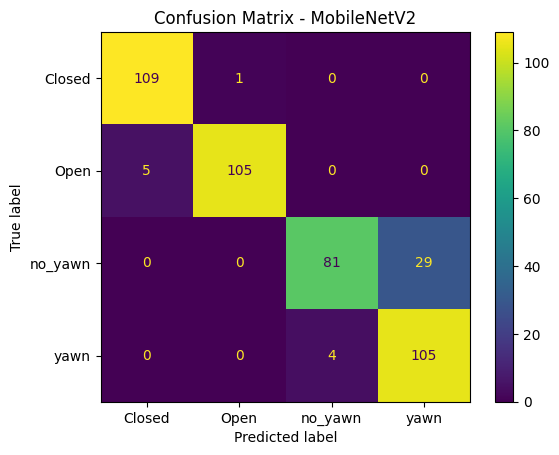

In [16]:
# ============ CONFUSION MATRIX ============
print("\n" + "="*50)
print("CONFUSION MATRIX (MobileNetV2)")
print("="*50)

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = mobilenet_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.title("Confusion Matrix - MobileNetV2")
plt.show()


In [17]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

      Closed       0.96      0.99      0.97       110
        Open       0.99      0.95      0.97       110
     no_yawn       0.95      0.74      0.83       110
        yawn       0.78      0.96      0.86       109

    accuracy                           0.91       439
   macro avg       0.92      0.91      0.91       439
weighted avg       0.92      0.91      0.91       439



In [18]:
# ============ FATIGUE LEVEL MAPPING ============
print("\n" + "="*50)
print("FATIGUE LEVEL MAPPING")
print("="*50)

fatigue_levels = []
for pred in y_pred:
    label = class_names[pred]
    if label == 'Closed':
        fatigue_levels.append(2)  # Severe Fatigue
    elif label == 'yawn':
        fatigue_levels.append(1)   # Mild Fatigue
    else:  # Open or no_yawn
        fatigue_levels.append(0)   # Alert

print(f"First 20 fatigue levels (0=Alert, 1=Mild, 2=Severe):")
print(fatigue_levels[:20])


FATIGUE LEVEL MAPPING
First 20 fatigue levels (0=Alert, 1=Mild, 2=Severe):
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [19]:
# ============ FATIGUE PROGRESSION CURVE ============
print("\n" + "="*50)
print("FATIGUE PROGRESSION OVER TIME")
print("="*50)

fatigue_progression = []
interval_size = 20  # frames per time block

for start_index in range(0, len(fatigue_levels), interval_size):
    end_index = start_index + interval_size
    time_interval_data = fatigue_levels[start_index:end_index]
    fatigue_counts = Counter(time_interval_data)
    dominant_fatigue_level = max(fatigue_counts, key=fatigue_counts.get)
    fatigue_progression.append(dominant_fatigue_level)

print(f"Fatigue level per time interval: {fatigue_progression}")


FATIGUE PROGRESSION OVER TIME
Fatigue level per time interval: [2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1]


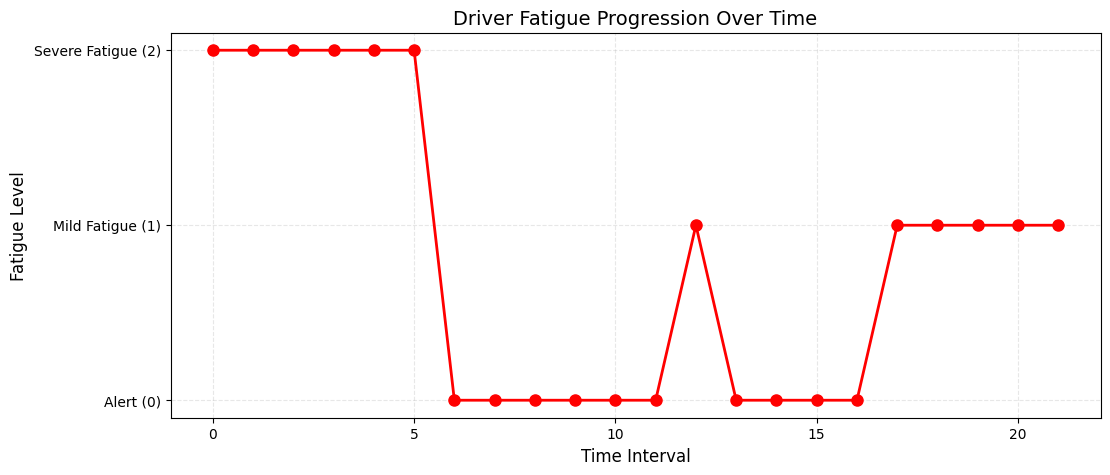

In [20]:
# Plot the fatigue progression curve
plt.figure(figsize=(12, 5))
plt.plot(fatigue_progression, marker='o', linewidth=2, markersize=8, color='red')
plt.xlabel('Time Interval', fontsize=12)
plt.ylabel('Fatigue Level', fontsize=12)
plt.title('Driver Fatigue Progression Over Time', fontsize=14)
plt.yticks([0, 1, 2], ['Alert (0)', 'Mild Fatigue (1)', 'Severe Fatigue (2)'])
plt.grid(True, alpha=0.3, linestyle='--')

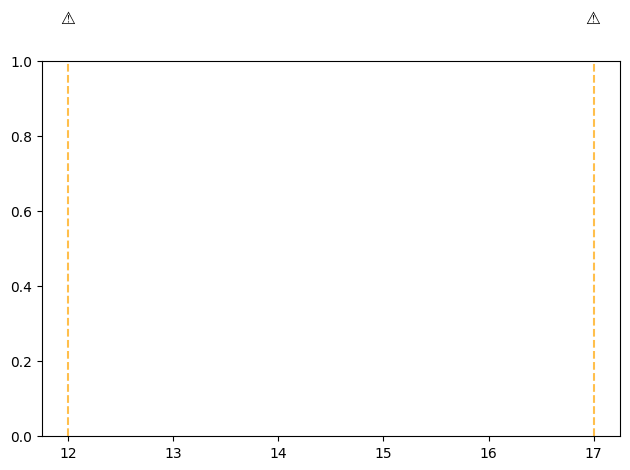

In [21]:
# Mark transition points
for i in range(1, len(fatigue_progression)):
    if fatigue_progression[i] > fatigue_progression[i-1]:
        plt.axvline(x=i, color='orange', linestyle='--', alpha=0.7, linewidth=1.5)
        plt.text(i, fatigue_progression[i] + 0.1, '⚠️', ha='center', fontsize=12)


plt.tight_layout()
plt.show()


In [22]:
# ============ FATIGUE TRANSITION ANALYSIS ============
print("\n" + "="*50)
print("FATIGUE TRANSITION ANALYSIS")
print("="*50)

for i in range(1, len(fatigue_progression)):
    if fatigue_progression[i] > fatigue_progression[i-1]:
        if fatigue_progression[i-1] == 0 and fatigue_progression[i] == 1:
            print(f"Interval {i}: Driver went from ALERT → MILD FATIGUE")
        elif fatigue_progression[i-1] == 1 and fatigue_progression[i] == 2:
            print(f"Interval {i}: Driver went from MILD FATIGUE → SEVERE FATIGUE")
        elif fatigue_progression[i-1] == 0 and fatigue_progression[i] == 2:
            print(f"Interval {i}: Driver went from ALERT → SEVERE FATIGUE (sudden)")

if len(fatigue_progression) > 0:
    print(f"\nFinal fatigue state: ", end="")
    if fatigue_progression[-1] == 0:
        print("ALERT")
    elif fatigue_progression[-1] == 1:
        print("MILD FATIGUE")
    else:
        print("SEVERE FATIGUE")


FATIGUE TRANSITION ANALYSIS
Interval 12: Driver went from ALERT → MILD FATIGUE
Interval 17: Driver went from ALERT → MILD FATIGUE

Final fatigue state: MILD FATIGUE
